In [1]:
import numpy as np
import gzip
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

try:
    from mt2 import mt2 as mt2_fn
except Exception:
    mt2_fn = None

In [2]:
def _open_lhe(path):
    return gzip.open(path, "rt") if str(path).endswith(".gz") else open(path, "rt")


def _to_table(rows, as_dataframe="auto"):
    if as_dataframe == "auto":
        as_dataframe = (pd is not None)

    if as_dataframe:
        if pd is None:
            raise ImportError(
                "pandas is not installed. Use as_dataframe=False or remove DataFrame output."
            )
        return pd.DataFrame(rows)

    return rows


def read_lhe_events(lhe_path, statuses=(1,)):
    """
    Read an LHE/LHE.GZ file into a list of events.

    Parameters
    ----------
    lhe_path : str
        Path to .lhe or .lhe.gz file.
    statuses : iterable of int or None
        Particle status codes to keep.
        Use (1,) for final-state outgoing particles.
        Use None to keep all particle records in each event.
    """
    events = []
    in_event = False
    skip_event_info = False
    current_event = []

    status_set = None if statuses is None else set(statuses)

    with _open_lhe(lhe_path) as f:
        for line in f:
            s = line.strip()

            if s == "<event>":
                in_event = True
                skip_event_info = True
                current_event = []
                continue

            if s == "</event>":
                events.append(current_event)
                in_event = False
                continue

            if not in_event or not s or s.startswith("#") or s.startswith("<"):
                continue

            if skip_event_info:
                skip_event_info = False
                continue

            cols = s.split()
            if len(cols) < 13:
                continue

            p = {
                "pid": int(cols[0]),
                "status": int(cols[1]),
                "mother1": int(cols[2]),
                "mother2": int(cols[3]),
                "color1": int(cols[4]),
                "color2": int(cols[5]),
                "px": float(cols[6]),
                "py": float(cols[7]),
                "pz": float(cols[8]),
                "E": float(cols[9]),
                "m": float(cols[10]),
                "vtim": float(cols[11]),
                "spin": float(cols[12]),
            }

            if status_set is None or p["status"] in status_set:
                current_event.append(p)

    return events


def read_lhe_outgoing(lhe_path):
    return read_lhe_events(lhe_path, statuses=(1,))


def pt(p):
    return np.hypot(p["px"], p["py"])


def p3(p):
    return np.sqrt(p["px"]**2 + p["py"]**2 + p["pz"]**2)


def phi(p):
    return np.arctan2(p["py"], p["px"])


def theta(p):
    denom = max(p3(p), 1e-15)
    return np.arccos(np.clip(p["pz"] / denom, -1.0, 1.0))


def eta(p):
    pabs = p3(p)
    if np.isclose(pabs, abs(p["pz"])):
        return np.sign(p["pz"]) * np.inf
    return 0.5 * np.log((pabs + p["pz"]) / (pabs - p["pz"]))


def fourvec(p):
    return np.array([p["E"], p["px"], p["py"], p["pz"]], dtype=float)


def inv_mass(*particles):
    q = np.sum([fourvec(p) for p in particles], axis=0)
    m2 = q[0]**2 - q[1]**2 - q[2]**2 - q[3]**2
    return np.sqrt(max(m2, 0.0))


def delta_phi(p1, p2):
    dphi = phi(p1) - phi(p2)
    return np.arctan2(np.sin(dphi), np.cos(dphi))


def delta_r(p1, p2):
    return np.hypot(eta(p1) - eta(p2), delta_phi(p1, p2))


def pair_pt(p1, p2):
    return np.hypot(p1["px"] + p2["px"], p1["py"] + p2["py"])


def met_from_particles(particles):
    if len(particles) == 0:
        return 0.0, 0.0, 0.0, 0.0
    px = sum(p["px"] for p in particles)
    py = sum(p["py"] for p in particles)
    met = np.hypot(px, py)
    met_phi = np.arctan2(py, px)
    return met, met_phi, px, py


def pid_is(*pids):
    wanted = set(pids)
    return lambda p: p["pid"] in wanted


def abs_pid_is(*abs_pids):
    wanted = set(abs_pids)
    return lambda p: abs(p["pid"]) in wanted


def combine_or(*selectors):
    return lambda p: any(sel(p) for sel in selectors)


def combine_and(*selectors):
    return lambda p: all(sel(p) for sel in selectors)


def _sort_particles(particles, sort_by="pt"):
    parts = list(particles)

    if sort_by == "pt":
        parts.sort(key=pt, reverse=True)
    elif sort_by == "E":
        parts.sort(key=lambda p: p["E"], reverse=True)
    elif sort_by is None:
        pass
    else:
        raise ValueError("sort_by must be 'pt', 'E', or None")

    return parts


def event_table(event, sort_by="pt", as_dataframe="auto"):
    parts = _sort_particles(event, sort_by=sort_by)

    rows = []
    for i, p in enumerate(parts):
        rows.append({
            "idx": i,
            "pid": p["pid"],
            "status": p["status"],
            "pt": pt(p),
            "eta": eta(p),
            "phi": phi(p),
            "theta": theta(p),
            "E": p["E"],
            "m": p["m"],
            "px": p["px"],
            "py": p["py"],
            "pz": p["pz"],
        })

    return _to_table(rows, as_dataframe=as_dataframe)


def analyze_pair_events(
    lhe_path,
    sel1,
    sel2,
    which1=0,
    which2=0,
    invisible=None,
    sort_by="pt",
    mt2_test_mass=0.0,
    as_dataframe="auto",
):
    events = read_lhe_outgoing(lhe_path)
    rows = []

    for ievt, event in enumerate(events):
        parts1 = _sort_particles([p for p in event if sel1(p)], sort_by=sort_by)
        parts2 = _sort_particles([p for p in event if sel2(p)], sort_by=sort_by)

        if len(parts1) <= which1 or len(parts2) <= which2:
            continue

        p1 = parts1[which1]
        p2 = parts2[which2]

        if p1 is p2:
            continue

        invisible_parts = [p for p in event if invisible(p)] if invisible else []
        met, met_phi, met_px, met_py = met_from_particles(invisible_parts)

        row = {
            "event": ievt,
            "pid1": p1["pid"],
            "pid2": p2["pid"],
            "pt1": pt(p1),
            "pt2": pt(p2),
            "eta1": eta(p1),
            "eta2": eta(p2),
            "phi1": phi(p1),
            "phi2": phi(p2),
            "E1": p1["E"],
            "E2": p2["E"],
            "m1": p1["m"],
            "m2": p2["m"],
            "deltaPhi": delta_phi(p1, p2),
            "deltaEta": eta(p1) - eta(p2),
            "deltaR": delta_r(p1, p2),
            "m12": inv_mass(p1, p2),
            "pt12": pair_pt(p1, p2),
            "MET": met,
            "MET_phi": met_phi,
            "MET_px": met_px,
            "MET_py": met_py,
            "n_invisible": len(invisible_parts),
        }

        if mt2_fn is not None and invisible is not None and len(invisible_parts) > 0:
            row["MT2"] = mt2_fn(
                p1["m"], p1["px"], p1["py"],
                p2["m"], p2["px"], p2["py"],
                met_px, met_py,
                mt2_test_mass, mt2_test_mass,
            )
        else:
            row["MT2"] = np.nan

        rows.append(row)

    return _to_table(rows, as_dataframe=as_dataframe)

In [3]:
cXe_ppZXll_path = "./LHEfiles/cXe_ppZXll_BSMEFT.lhe"
cXl_ppZXll_path = "./LHEfiles/cXl_ppZXll_BSMEFT.lhe"
cdhielx_ppZXll_path = "./LHEfiles/cdhielx_ppZXll_BSMEFT.lhe"
cdhieslx_ppZXll_path = "./LHEfiles/cdhieslx_ppZXll_BSMEFT.lhe"
SM_ppvvll_path = "./LHEfiles/ppvvll_SM.lhe"

cXe_ppZXll_events = read_lhe_outgoing(cXe_ppZXll_path)
cXl_ppZXll_events = read_lhe_outgoing(cXl_ppZXll_path)
cdhielx_ppZXll_events = read_lhe_outgoing(cdhielx_ppZXll_path)
cdhieslx_ppZXll_events = read_lhe_outgoing(cdhieslx_ppZXll_path)
SM_ppvvll_events = read_lhe_outgoing(SM_ppvvll_path)

# Inspect one event and see what outgoing particles are there
event_table(cXe_ppZXll_events[0])

,idx,pid,status,pt,eta,phi,theta,E,m,px,py,pz
0,0,-11,1,680.470907,1.176664,0.850572,0.598118,1208.461969,0.000511,448.806891,511.481211,998.668952
1,1,9000002,1,637.883792,0.701891,-1.954969,0.920318,801.630859,10.000000,-239.073866,-591.387706,485.403237
2,2,11,1,224.439279,-0.628097,2.777580,2.161253,270.185311,0.000511,-209.733026,79.906495,-150.423110


In [4]:
charged_lepton = abs_pid_is(11, 13, 15)
dark_xx = abs_pid_is(9000002)

rows = analyze_pair_events(
    cXe_ppZXll_path,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    invisible=dark_xx,
    sort_by="pt",
)

cols = ["event", "pid1", "pid2", "pt1", "pt2", "deltaR", "m12", "MET", "MT2"]

if pd is not None:
    display(pd.DataFrame(rows)[cols].head())
else:
    display([{c: row[c] for c in cols} for row in rows[:5]])

,event,pid1,pid2,pt1,pt2,deltaR,m12,MET,MT2
0,0,-11,11,680.470907,224.439279,2.640174,1029.553805,637.883792,446.016689
1,1,-11,11,303.393845,140.986635,4.561727,1479.337058,226.893865,158.444703
2,2,-11,11,936.281102,255.691204,1.017313,504.558741,1156.545403,935.090722
3,3,11,-11,677.813860,405.094922,2.629283,1337.216115,627.357161,564.979104
4,4,-11,11,510.623353,480.726325,2.415151,928.618215,355.676728,354.417977


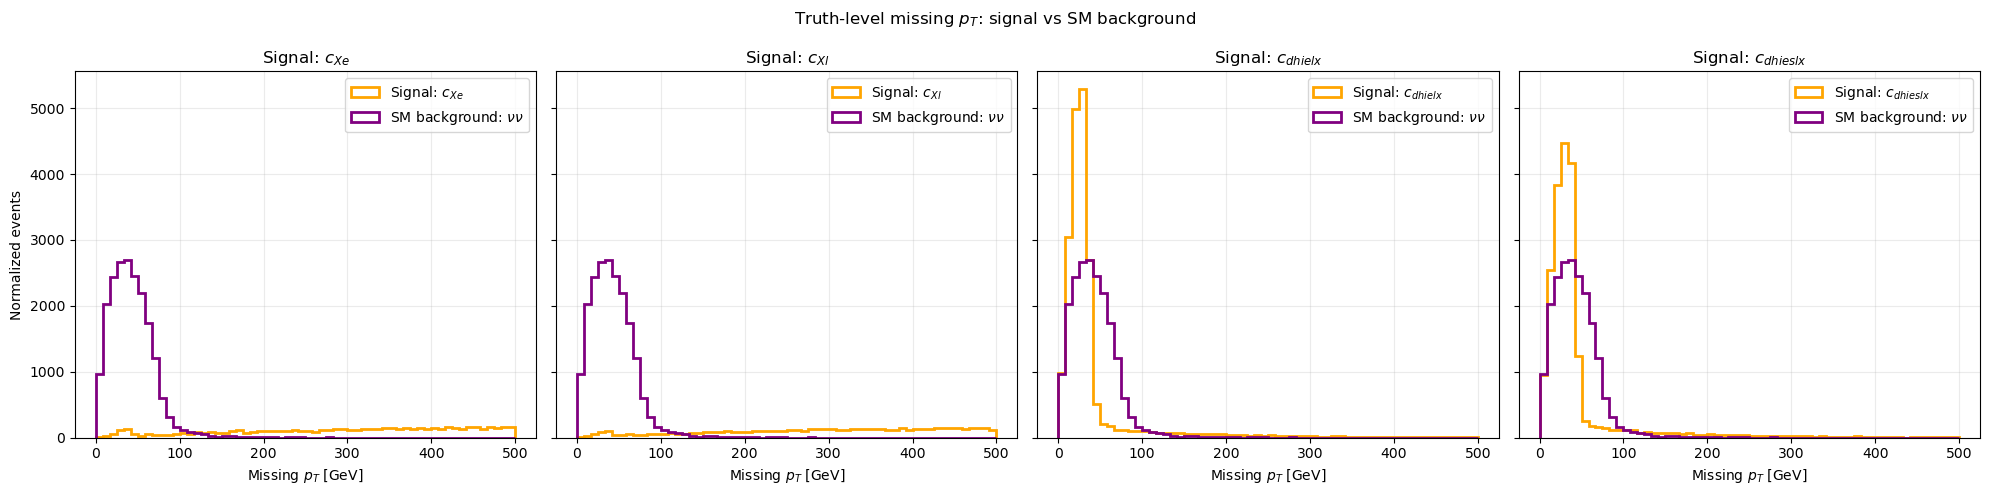

Signal: $c_{Xe}$
  Signal events      = 20000
  Background events  = 20000
  Signal mean MET    = 818.542 GeV
  Background mean MET= 42.481 GeV
Signal: $c_{Xl}$
  Signal events      = 20000
  Background events  = 20000
  Signal mean MET    = 843.249 GeV
  Background mean MET= 42.481 GeV
Signal: $c_{dhielx}$
  Signal events      = 20000
  Background events  = 20000
  Signal mean MET    = 47.255 GeV
  Background mean MET= 42.481 GeV
Signal: $c_{dhieslx}$
  Signal events      = 20000
  Background events  = 20000
  Signal mean MET    = 50.706 GeV
  Background mean MET= 42.481 GeV


In [11]:
dark_xx   = abs_pid_is(9000002)
neutrinos = abs_pid_is(12, 14, 16)
signal_samples = {
    r"Signal: $c_{Xe}$": cXe_ppZXll_path,
    r"Signal: $c_{Xl}$": cXl_ppZXll_path,
    r"Signal: $c_{dhielx}$": cdhielx_ppZXll_path,
    r"Signal: $c_{dhieslx}$": cdhieslx_ppZXll_path,
}

bkg_events = read_lhe_outgoing(SM_ppvvll_path)
bkg_missing_pt = np.array([
    met_from_particles([p for p in event if neutrinos(p)])[0]
    for event in bkg_events
])

signal_missing_pts = {}
for label, lhe_path in signal_samples.items():
    signal_events = read_lhe_outgoing(lhe_path)
    signal_missing_pts[label] = np.array([
        met_from_particles([p for p in event if dark_xx(p)])[0]
        for event in signal_events
    ])

xmin = 0.0
xmax_plot = 500.0   # or None for automatic max
nbins = 60

if xmax_plot is None:
    xmax_plot = max(
        [bkg_missing_pt.max()] + [arr.max() for arr in signal_missing_pts.values()]
    )

bins = np.linspace(xmin, xmax_plot, nbins + 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, (label, signal_missing_pt) in zip(axes, signal_missing_pts.items()):
    ax.hist(signal_missing_pt, bins=bins, histtype="step", linewidth=2, color="orange",
            density=False, label=label)
    ax.hist(bkg_missing_pt, bins=bins, histtype="step", linewidth=2, color="purple",
            density=False, label=r"SM background: $\nu\nu$")
    ax.set_xlabel(r"Missing $p_T$ [GeV]")
    ax.set_title(label)
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel("Normalized events")
fig.suptitle(r"Truth-level missing $p_T$: signal vs SM background")
plt.tight_layout()
plt.show()

for label, signal_missing_pt in signal_missing_pts.items():
    print(label)
    print(f"  Signal events      = {len(signal_missing_pt)}")
    print(f"  Background events  = {len(bkg_missing_pt)}")
    print(f"  Signal mean MET    = {signal_missing_pt.mean():.3f} GeV")
    print(f"  Background mean MET= {bkg_missing_pt.mean():.3f} GeV")

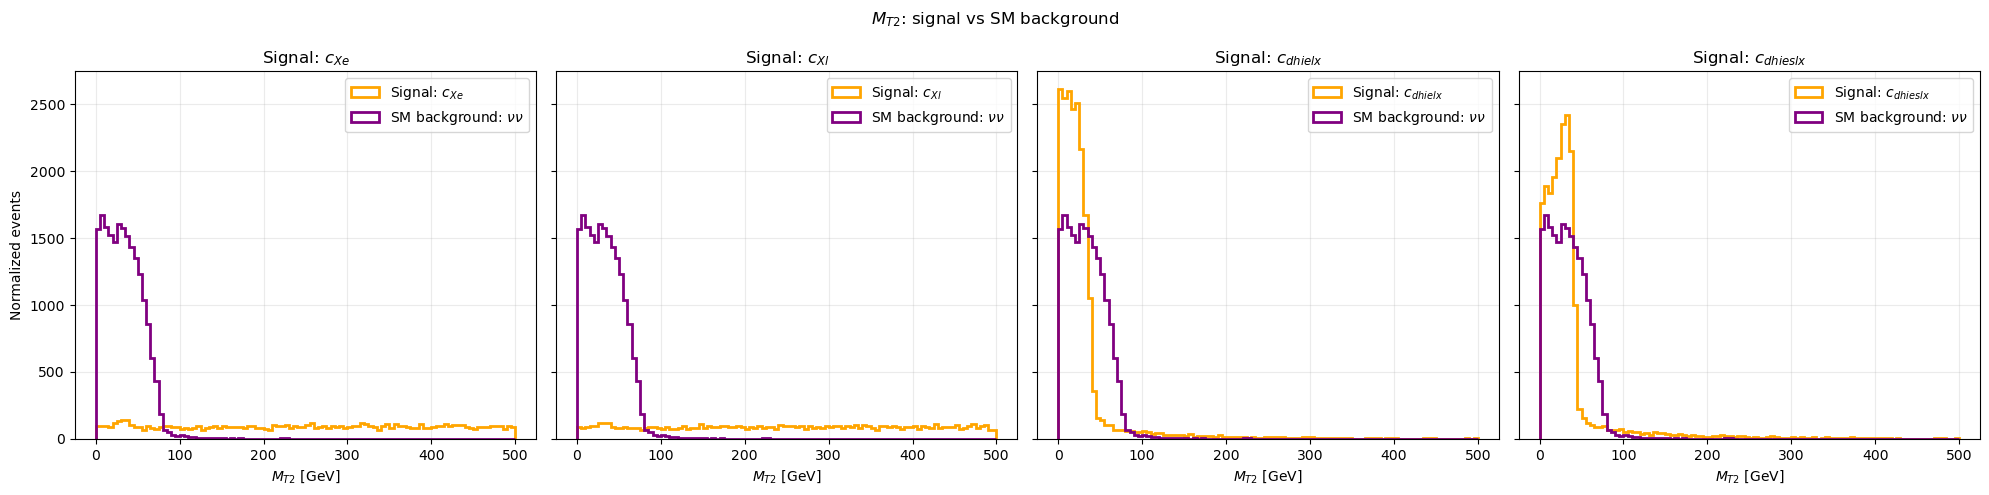

Signal: $c_{Xe}$
  Signal MT2 entries      = 20000
  Background MT2 entries  = 20000
  Signal mean MT2         = 649.971 GeV
  Background mean MT2     = 33.976 GeV
Signal: $c_{Xl}$
  Signal MT2 entries      = 20000
  Background MT2 entries  = 20000
  Signal mean MT2         = 668.622 GeV
  Background mean MT2     = 33.976 GeV
Signal: $c_{dhielx}$
  Signal MT2 entries      = 20000
  Background MT2 entries  = 20000
  Signal mean MT2         = 32.113 GeV
  Background mean MT2     = 33.976 GeV
Signal: $c_{dhieslx}$
  Signal MT2 entries      = 20000
  Background MT2 entries  = 20000
  Signal mean MT2         = 40.433 GeV
  Background mean MT2     = 33.976 GeV


In [23]:
if mt2_fn is None:
    raise RuntimeError("mt2 is not available in this kernel, so MT2 cannot be computed.")

charged_lepton = abs_pid_is(11, 13, 15)
dark_xx        = abs_pid_is(9000002)
neutrinos      = abs_pid_is(12, 14, 16)


bkg_rows = analyze_pair_events(
    SM_ppvvll_path,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    invisible=neutrinos,
    sort_by="pt",
    mt2_test_mass=0.0,
    as_dataframe=False
)


bkg_mt2 = np.array([
    row["MT2"] for row in bkg_rows
    if np.isfinite(row["MT2"]) and row["MT2"] >= 0
])

signal_mt2s = {}
for label, lhe_path in signal_samples.items():
    signal_rows = analyze_pair_events(
        lhe_path,
        sel1=charged_lepton,
        sel2=charged_lepton,
        which1=0,
        which2=1,
        invisible=dark_xx,
        sort_by="pt",
        mt2_test_mass=0.0,
        as_dataframe=False
    )

    signal_mt2s[label] = np.array([
        row["MT2"] for row in signal_rows
        if np.isfinite(row["MT2"]) and row["MT2"] >= 0
    ])

xmin = 0.0
xmax_plot = 500   # or set e.g. 2500.0
nbins = 100

if xmax_plot is None:
    xmax_plot = max([bkg_mt2.max()] + [arr.max() for arr in signal_mt2s.values()])

bins = np.linspace(xmin, xmax_plot, nbins + 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, (label, signal_mt2) in zip(axes, signal_mt2s.items()):
    ax.hist(signal_mt2, bins=bins, histtype="step", linewidth=2, color="orange",
            density=False, label=label)
    ax.hist(bkg_mt2, bins=bins, histtype="step", linewidth=2, color="purple",
            density=False, label=r"SM background: $\nu\nu$")
    ax.set_xlabel(r"$M_{T2}$ [GeV]")
    ax.set_title(label)
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel("Normalized events")
fig.suptitle(r"$M_{T2}$: signal vs SM background")
plt.tight_layout()
plt.show()

for label, signal_mt2 in signal_mt2s.items():
    print(label)
    print(f"  Signal MT2 entries      = {len(signal_mt2)}")
    print(f"  Background MT2 entries  = {len(bkg_mt2)}")
    print(f"  Signal mean MT2         = {signal_mt2.mean():.3f} GeV")
    print(f"  Background mean MT2     = {bkg_mt2.mean():.3f} GeV")

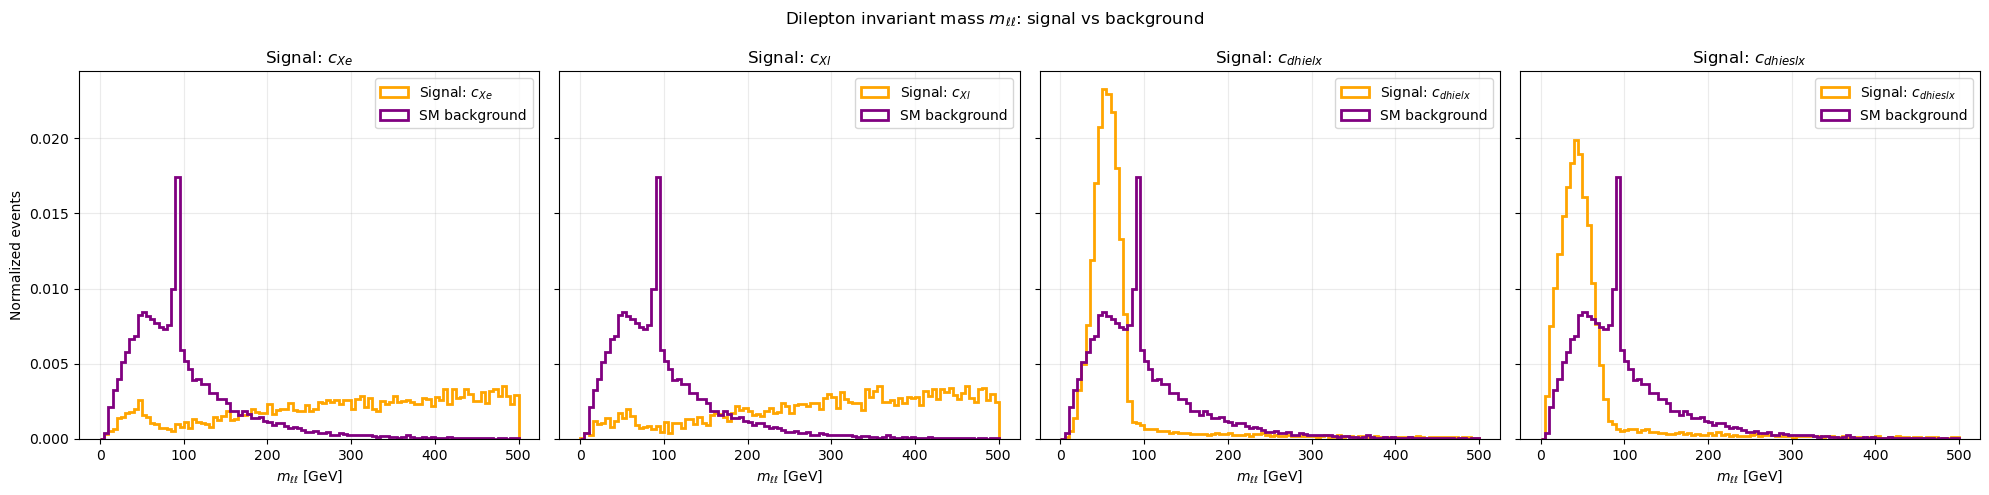

Signal: $c_{Xe}$
  Signal entries        = 20000
  Background entries    = 20000
  Signal mean m_ll      = 1157.919 GeV
  Background mean m_ll  = 102.614 GeV

Signal: $c_{Xl}$
  Signal entries        = 20000
  Background entries    = 20000
  Signal mean m_ll      = 1196.967 GeV
  Background mean m_ll  = 102.614 GeV

Signal: $c_{dhielx}$
  Signal entries        = 20000
  Background entries    = 20000
  Signal mean m_ll      = 100.508 GeV
  Background mean m_ll  = 102.614 GeV

Signal: $c_{dhieslx}$
  Signal entries        = 20000
  Background entries    = 20000
  Signal mean m_ll      = 81.595 GeV
  Background mean m_ll  = 102.614 GeV



In [24]:
charged_lepton = abs_pid_is(11, 13, 15)

# Process background
bkg_rows = analyze_pair_events(
    SM_ppvvll_path,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    sort_by="pt",
    as_dataframe=False,
)

bkg_mll = np.array([row["m12"] for row in bkg_rows if np.isfinite(row["m12"])])

# Process signal samples
signal_mlls = {}
for label, lhe_path in signal_samples.items():
    signal_rows = analyze_pair_events(
        lhe_path,
        sel1=charged_lepton,
        sel2=charged_lepton,
        which1=0,
        which2=1,
        sort_by="pt",
        as_dataframe=False,
    )

    signal_mlls[label] = np.array(
        [row["m12"] for row in signal_rows if np.isfinite(row["m12"])]
    )

# Histogram settings
xmin = 0.0
xmax_plot = 500.0  # Set fixed x-limit or None for dynamic range
nbins = 100

if xmax_plot is None:
    xmax_plot = max(
        [bkg_mll.max()] + [arr.max() for arr in signal_mlls.values()]
    )

bins = np.linspace(xmin, xmax_plot, nbins + 1)

# Plotting: 1 row x 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

# Loop over subplots and signals
for ax, (label, signal_mll) in zip(axes, signal_mlls.items()):
    ax.hist(
        signal_mll,
        bins=bins,
        histtype="step",
        linewidth=2,
        color="orange",
        density=True,
        label=label,
    )
    ax.hist(
        bkg_mll,
        bins=bins,
        histtype="step",
        linewidth=2,
        color="purple",
        density=True,
        label="SM background",
    )
    ax.set_xlabel(r"$m_{\ell\ell}$ [GeV]")
    ax.set_title(label)
    ax.grid(alpha=0.25)
    ax.legend()

# Hide any unused subplot axes if fewer than 4 signal samples are provided
for ax in axes[len(signal_mlls) :]:
    ax.set_visible(False)

axes[0].set_ylabel("Normalized events")
fig.suptitle(r"Dilepton invariant mass $m_{\ell\ell}$: signal vs background")
plt.tight_layout()
plt.show()

# Print statistics
for label, signal_mll in signal_mlls.items():
    print(label)
    print(f"  Signal entries        = {len(signal_mll)}")
    print(f"  Background entries    = {len(bkg_mll)}")
    print(f"  Signal mean m_ll      = {signal_mll.mean():.3f} GeV")
    print(f"  Background mean m_ll  = {bkg_mll.mean():.3f} GeV\n")

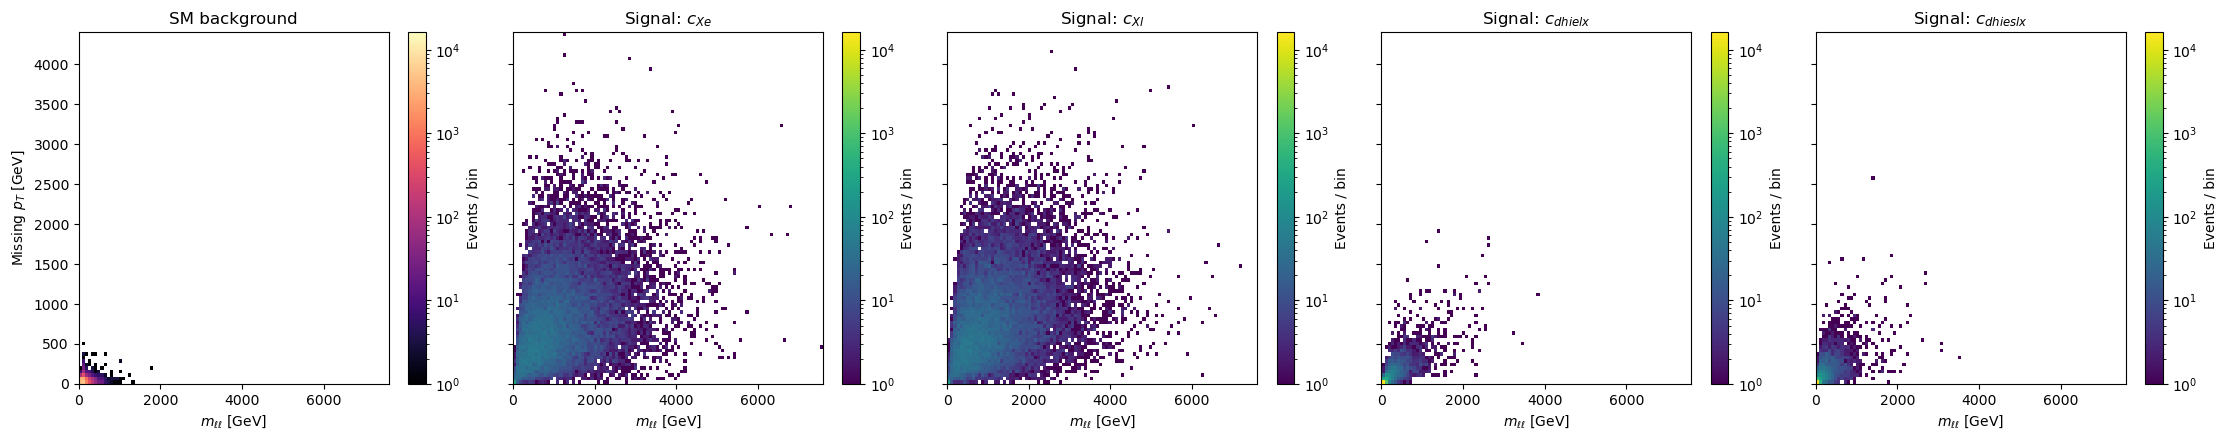

In [25]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np

charged_lepton = abs_pid_is(11, 13, 15)
dark_xx = abs_pid_is(9000002)
neutrinos = abs_pid_is(12, 14, 16)

# Process background
bkg_rows = analyze_pair_events(
    SM_ppvvll_path,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    invisible=neutrinos,
    sort_by="pt",
    as_dataframe=False,
)

bkg_mll = np.array(
    [
        row["m12"]
        for row in bkg_rows
        if np.isfinite(row["m12"]) and np.isfinite(row["MET"])
    ]
)
bkg_met = np.array(
    [
        row["MET"]
        for row in bkg_rows
        if np.isfinite(row["m12"]) and np.isfinite(row["MET"])
    ]
)

# Process signal samples
signal_data = {}
for label, lhe_path in signal_samples.items():
    signal_rows = analyze_pair_events(
        lhe_path,
        sel1=charged_lepton,
        sel2=charged_lepton,
        which1=0,
        which2=1,
        invisible=dark_xx,
        sort_by="pt",
        as_dataframe=False,
    )

    mll = np.array(
        [
            row["m12"]
            for row in signal_rows
            if np.isfinite(row["m12"]) and np.isfinite(row["MET"])
        ]
    )
    met = np.array(
        [
            row["MET"]
            for row in signal_rows
            if np.isfinite(row["m12"]) and np.isfinite(row["MET"])
        ]
    )
    signal_data[label] = {"mll": mll, "met": met}

# Determine bin ranges across all samples
mll_max = max(
    [bkg_mll.max()]
    + [data["mll"].max() for data in signal_data.values() if len(data["mll"]) > 0]
)
met_max = max(
    [bkg_met.max()]
    + [data["met"].max() for data in signal_data.values() if len(data["met"]) > 0]
)

nbins_mll = 100
nbins_met = 100

mll_bins = np.linspace(0.0, mll_max, nbins_mll + 1)
met_bins = np.linspace(0.0, met_max, nbins_met + 1)

# Find maximum bin content across all datasets for a unified LogNorm color scale
bkg_H, _, _ = np.histogram2d(bkg_mll, bkg_met, bins=[mll_bins, met_bins])
max_counts = [bkg_H.max()]

for data in signal_data.values():
    sig_H, _, _ = np.histogram2d(
        data["mll"], data["met"], bins=[mll_bins, met_bins]
    )
    max_counts.append(sig_H.max())

vmax = max(max_counts)
norm = LogNorm(vmin=1, vmax=vmax)

# Plotting: 1 panel for SM background + 1 panel per signal sample
n_plots = 1 + len(signal_data)
fig, axes = plt.subplots(
    1, n_plots, figsize=(4.5 * n_plots, 4.5), sharex=True, sharey=True
)

if n_plots == 1:
    axes = [axes]

# Plot Background
h_bkg = axes[0].hist2d(
    bkg_mll,
    bkg_met,
    bins=[mll_bins, met_bins],
    cmap="magma",
    norm=norm,
)
axes[0].set_title("SM background")
axes[0].set_xlabel(r"$m_{\ell\ell}$ [GeV]")
axes[0].set_ylabel(r"Missing $p_T$ [GeV]")
fig.colorbar(h_bkg[3], ax=axes[0], label="Events / bin")

# Plot Signals
for ax, (label, data) in zip(axes[1:], signal_data.items()):
    h_sig = ax.hist2d(
        data["mll"],
        data["met"],
        bins=[mll_bins, met_bins],
        cmap="viridis",
        norm=norm,
    )
    ax.set_title(label)
    ax.set_xlabel(r"$m_{\ell\ell}$ [GeV]")
    fig.colorbar(h_sig[3], ax=ax, label="Events / bin")

# Hide unused subplot axes if fewer samples are present
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

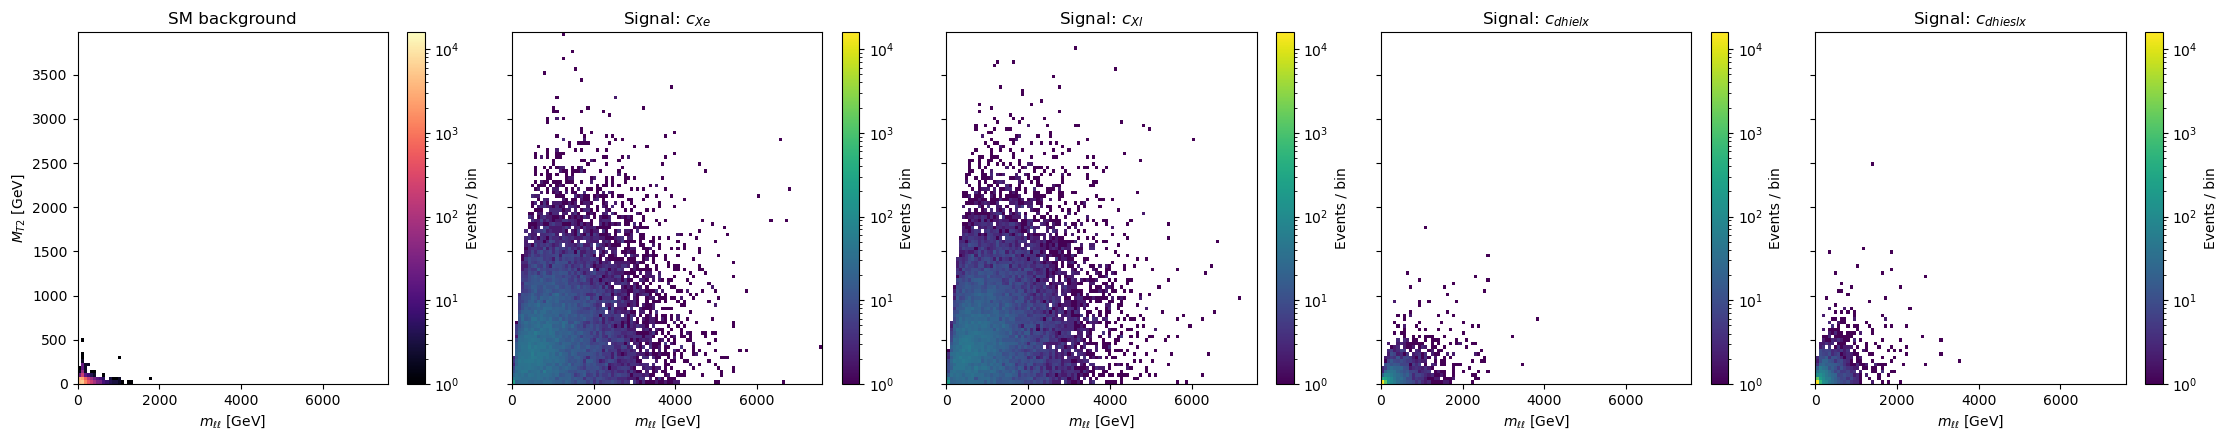

In [26]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np

if mt2_fn is None:
    raise RuntimeError(
        "mt2 is not available in this kernel, so MT2 cannot be computed."
    )


charged_lepton = abs_pid_is(11, 13, 15)
dark_xx = abs_pid_is(9000002)
neutrinos = abs_pid_is(12, 14, 16)

# Process background
bkg_rows = analyze_pair_events(
    SM_ppvvll_path,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    invisible=neutrinos,
    sort_by="pt",
    mt2_test_mass=0.0,
    as_dataframe=False,
)

bkg_pairs = [
    (row["m12"], row["MT2"])
    for row in bkg_rows
    if np.isfinite(row["m12"]) and np.isfinite(row["MT2"]) and row["MT2"] >= 0
]
bkg_mll = np.array([x[0] for x in bkg_pairs])
bkg_mt2 = np.array([x[1] for x in bkg_pairs])

# Process signal samples
signal_data = {}
for label, lhe_path in signal_samples.items():
    signal_rows = analyze_pair_events(
        lhe_path,
        sel1=charged_lepton,
        sel2=charged_lepton,
        which1=0,
        which2=1,
        invisible=dark_xx,
        sort_by="pt",
        mt2_test_mass=0.0,
        as_dataframe=False,
    )

    sig_pairs = [
        (row["m12"], row["MT2"])
        for row in signal_rows
        if np.isfinite(row["m12"])
        and np.isfinite(row["MT2"])
        and row["MT2"] >= 0
    ]
    mll = np.array([x[0] for x in sig_pairs])
    mt2 = np.array([x[1] for x in sig_pairs])
    signal_data[label] = {"mll": mll, "mt2": mt2}

# Determine bin ranges across all samples
mll_max = max(
    [bkg_mll.max()]
    + [
        data["mll"].max()
        for data in signal_data.values()
        if len(data["mll"]) > 0
    ]
)
mt2_max = max(
    [bkg_mt2.max()]
    + [
        data["mt2"].max()
        for data in signal_data.values()
        if len(data["mt2"]) > 0
    ]
)

nbins_mll = 100
nbins_mt2 = 100

mll_bins = np.linspace(0.0, mll_max, nbins_mll + 1)
mt2_bins = np.linspace(0.0, mt2_max, nbins_mt2 + 1)

# Find maximum bin content across all datasets for a unified LogNorm color scale
bkg_H, _, _ = np.histogram2d(bkg_mll, bkg_mt2, bins=[mll_bins, mt2_bins])
max_counts = [bkg_H.max()]

for data in signal_data.values():
    sig_H, _, _ = np.histogram2d(
        data["mll"], data["mt2"], bins=[mll_bins, mt2_bins]
    )
    max_counts.append(sig_H.max())

vmax = max(max_counts)
norm = LogNorm(vmin=1, vmax=vmax)

# Plotting: 1 panel for SM background + 1 panel per signal sample
n_plots = 1 + len(signal_data)
fig, axes = plt.subplots(
    1, n_plots, figsize=(4.5 * n_plots, 4.5), sharex=True, sharey=True
)

if n_plots == 1:
    axes = [axes]

# Plot Background
h_bkg = axes[0].hist2d(
    bkg_mll,
    bkg_mt2,
    bins=[mll_bins, mt2_bins],
    cmap="magma",
    norm=norm,
)
axes[0].set_title("SM background")
axes[0].set_xlabel(r"$m_{\ell\ell}$ [GeV]")
axes[0].set_ylabel(r"$M_{T2}$ [GeV]")
fig.colorbar(h_bkg[3], ax=axes[0], label="Events / bin")

# Plot Signals
for ax, (label, data) in zip(axes[1:], signal_data.items()):
    h_sig = ax.hist2d(
        data["mll"],
        data["mt2"],
        bins=[mll_bins, mt2_bins],
        cmap="viridis",
        norm=norm,
    )
    ax.set_title(label)
    ax.set_xlabel(r"$m_{\ell\ell}$ [GeV]")
    fig.colorbar(h_sig[3], ax=ax, label="Events / bin")

# Hide unused subplot axes if fewer samples are present
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Scrap

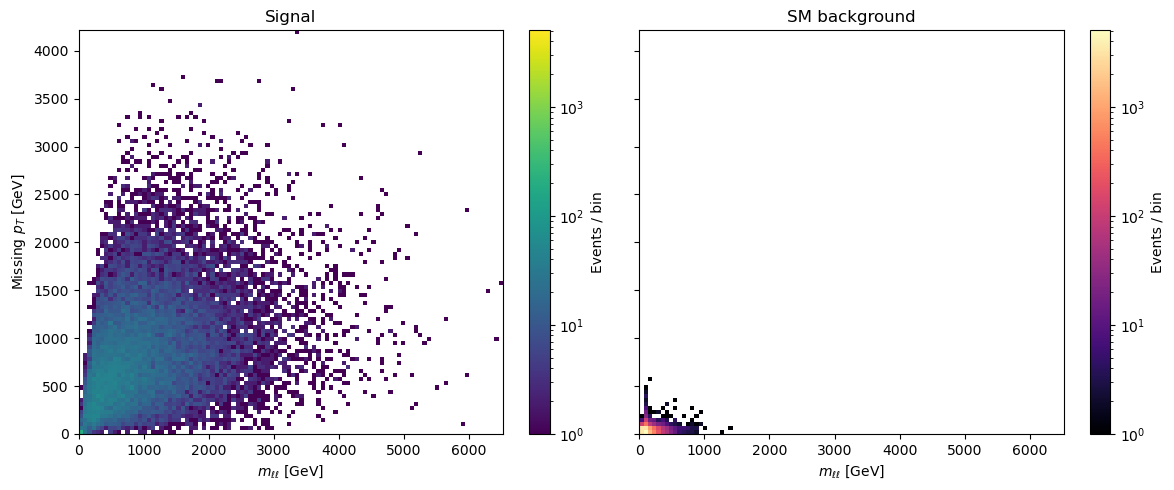

In [34]:
from matplotlib.colors import LogNorm

signal_lhe = "../lhe_files/cXe_ppZXll_BSMEFT/Events/run_01/unweighted_events.lhe"
bkg_lhe    = "../lhe_files/ppvvll_SM/Events/run_01/unweighted_events.lhe"

charged_lepton = abs_pid_is(11, 13, 15)
dark_xx        = abs_pid_is(9000002)
neutrinos      = abs_pid_is(12, 14, 16)

signal_rows = analyze_pair_events(
    signal_lhe,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    invisible=dark_xx,
    sort_by="pt",
)

bkg_rows = analyze_pair_events(
    bkg_lhe,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    invisible=neutrinos,
    sort_by="pt",
)

signal_mll = np.array([row["m12"] for row in signal_rows if np.isfinite(row["m12"]) and np.isfinite(row["MET"])])
signal_met = np.array([row["MET"] for row in signal_rows if np.isfinite(row["m12"]) and np.isfinite(row["MET"])])

bkg_mll = np.array([row["m12"] for row in bkg_rows if np.isfinite(row["m12"]) and np.isfinite(row["MET"])])
bkg_met = np.array([row["MET"] for row in bkg_rows if np.isfinite(row["m12"]) and np.isfinite(row["MET"])])

mll_max = max(signal_mll.max(), bkg_mll.max())
met_max = max(signal_met.max(), bkg_met.max())

nbins_mll = 100
nbins_met = 100

mll_bins = np.linspace(0.0, mll_max, nbins_mll + 1)
met_bins = np.linspace(0.0, met_max, nbins_met + 1)

sig_H, _, _ = np.histogram2d(signal_mll, signal_met, bins=[mll_bins, met_bins])
bkg_H, _, _ = np.histogram2d(bkg_mll, bkg_met, bins=[mll_bins, met_bins])

vmax = max(sig_H.max(), bkg_H.max())
norm = LogNorm(vmin=1, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

h1 = axes[0].hist2d(signal_mll, signal_met, bins=[mll_bins, met_bins],
                    cmap="viridis", norm=norm)
axes[0].set_title("Signal")
axes[0].set_xlabel(r"$m_{\ell\ell}$ [GeV]")
axes[0].set_ylabel(r"Missing $p_T$ [GeV]")
fig.colorbar(h1[3], ax=axes[0], label="Events / bin")

h2 = axes[1].hist2d(bkg_mll, bkg_met, bins=[mll_bins, met_bins],
                    cmap="magma", norm=norm)
axes[1].set_title("SM background")
axes[1].set_xlabel(r"$m_{\ell\ell}$ [GeV]")
fig.colorbar(h2[3], ax=axes[1], label="Events / bin")

plt.tight_layout()
plt.show()

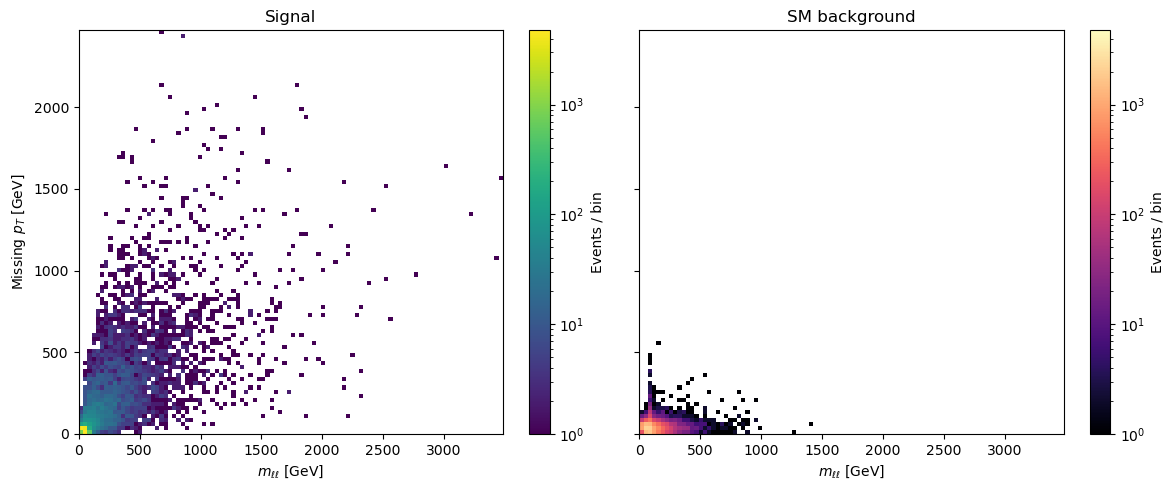

In [50]:
from matplotlib.colors import LogNorm

signal_lhe = "../lhe_files/cdhieslx_ppZXll_BSMEFT/Events/run_01/unweighted_events.lhe"
bkg_lhe    = "../lhe_files/ppvvll_SM/Events/run_01/unweighted_events.lhe"

charged_lepton = abs_pid_is(11, 13, 15)
dark_xx        = abs_pid_is(9000002)
neutrinos      = abs_pid_is(12, 14, 16)

signal_rows = analyze_pair_events(
    signal_lhe,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    invisible=dark_xx,
    sort_by="pt",
)

bkg_rows = analyze_pair_events(
    bkg_lhe,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    invisible=neutrinos,
    sort_by="pt",
)

signal_mll = np.array([row["m12"] for row in signal_rows if np.isfinite(row["m12"]) and np.isfinite(row["MET"])])
signal_met = np.array([row["MET"] for row in signal_rows if np.isfinite(row["m12"]) and np.isfinite(row["MET"])])

bkg_mll = np.array([row["m12"] for row in bkg_rows if np.isfinite(row["m12"]) and np.isfinite(row["MET"])])
bkg_met = np.array([row["MET"] for row in bkg_rows if np.isfinite(row["m12"]) and np.isfinite(row["MET"])])

mll_max = max(signal_mll.max(), bkg_mll.max())
met_max = max(signal_met.max(), bkg_met.max())

nbins_mll = 100
nbins_met = 100

mll_bins = np.linspace(0.0, mll_max, nbins_mll + 1)
met_bins = np.linspace(0.0, met_max, nbins_met + 1)

sig_H, _, _ = np.histogram2d(signal_mll, signal_met, bins=[mll_bins, met_bins])
bkg_H, _, _ = np.histogram2d(bkg_mll, bkg_met, bins=[mll_bins, met_bins])

vmax = max(sig_H.max(), bkg_H.max())
norm = LogNorm(vmin=1, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

h1 = axes[0].hist2d(signal_mll, signal_met, bins=[mll_bins, met_bins],
                    cmap="viridis", norm=norm)
axes[0].set_title("Signal")
axes[0].set_xlabel(r"$m_{\ell\ell}$ [GeV]")
axes[0].set_ylabel(r"Missing $p_T$ [GeV]")
fig.colorbar(h1[3], ax=axes[0], label="Events / bin")

h2 = axes[1].hist2d(bkg_mll, bkg_met, bins=[mll_bins, met_bins],
                    cmap="magma", norm=norm)
axes[1].set_title("SM background")
axes[1].set_xlabel(r"$m_{\ell\ell}$ [GeV]")
fig.colorbar(h2[3], ax=axes[1], label="Events / bin")

plt.tight_layout()
plt.show()

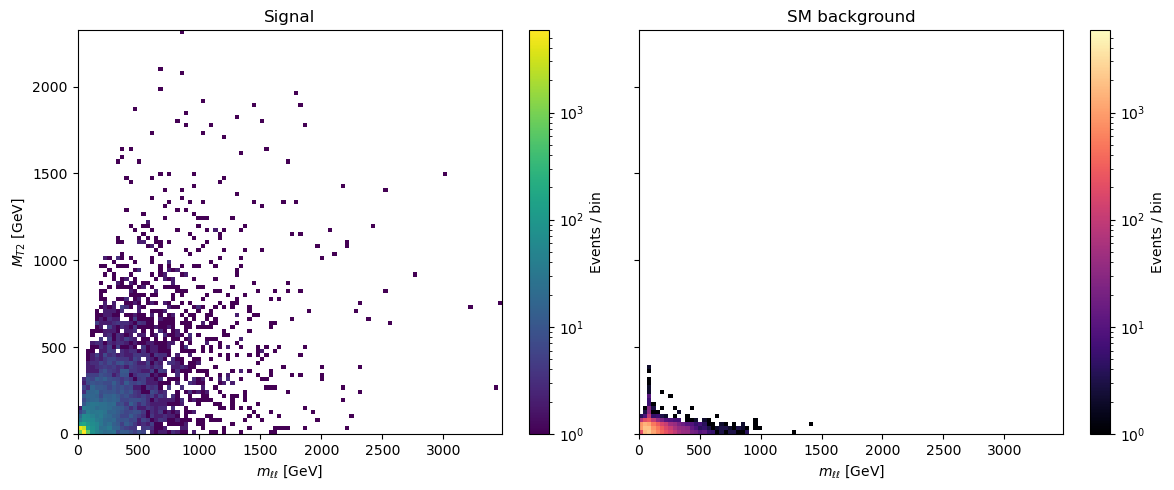

In [49]:
from matplotlib.colors import LogNorm

if mt2_fn is None:
    raise RuntimeError("mt2 is not available in this kernel, so MT2 cannot be computed.")

signal_lhe = "../lhe_files/cdhieslx_ppZXll_BSMEFT/Events/run_01/unweighted_events.lhe"
bkg_lhe    = "../lhe_files/ppvvll_SM/Events/run_01/unweighted_events.lhe"

charged_lepton = abs_pid_is(11, 13, 15)
dark_xx        = abs_pid_is(9000002)
neutrinos      = abs_pid_is(12, 14, 16)

signal_rows = analyze_pair_events(
    signal_lhe,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    invisible=dark_xx,
    sort_by="pt",
    mt2_test_mass=0.0,
)

bkg_rows = analyze_pair_events(
    bkg_lhe,
    sel1=charged_lepton,
    sel2=charged_lepton,
    which1=0,
    which2=1,
    invisible=neutrinos,
    sort_by="pt",
    mt2_test_mass=0.0,
)

signal_pairs = [
    (row["m12"], row["MT2"])
    for row in signal_rows
    if np.isfinite(row["m12"]) and np.isfinite(row["MT2"]) and row["MT2"] >= 0
]

bkg_pairs = [
    (row["m12"], row["MT2"])
    for row in bkg_rows
    if np.isfinite(row["m12"]) and np.isfinite(row["MT2"]) and row["MT2"] >= 0
]

signal_mll = np.array([x[0] for x in signal_pairs])
signal_mt2 = np.array([x[1] for x in signal_pairs])

bkg_mll = np.array([x[0] for x in bkg_pairs])
bkg_mt2 = np.array([x[1] for x in bkg_pairs])

mll_max = max(signal_mll.max(), bkg_mll.max())
mt2_max = max(signal_mt2.max(), bkg_mt2.max())

nbins_mll = 100
nbins_mt2 = 100

mll_bins = np.linspace(0.0, mll_max, nbins_mll + 1)
mt2_bins = np.linspace(0.0, mt2_max, nbins_mt2 + 1)

sig_H, _, _ = np.histogram2d(signal_mll, signal_mt2, bins=[mll_bins, mt2_bins])
bkg_H, _, _ = np.histogram2d(bkg_mll, bkg_mt2, bins=[mll_bins, mt2_bins])

vmax = max(sig_H.max(), bkg_H.max())
norm = LogNorm(vmin=1, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

h1 = axes[0].hist2d(signal_mll, signal_mt2, bins=[mll_bins, mt2_bins],
                    cmap="viridis", norm=norm)
axes[0].set_title("Signal")
axes[0].set_xlabel(r"$m_{\ell\ell}$ [GeV]")
axes[0].set_ylabel(r"$M_{T2}$ [GeV]")
fig.colorbar(h1[3], ax=axes[0], label="Events / bin")

h2 = axes[1].hist2d(bkg_mll, bkg_mt2, bins=[mll_bins, mt2_bins],
                    cmap="magma", norm=norm)
axes[1].set_title("SM background")
axes[1].set_xlabel(r"$m_{\ell\ell}$ [GeV]")
fig.colorbar(h2[3], ax=axes[1], label="Events / bin")

plt.tight_layout()
plt.show()